In [12]:
# 1/2026, Focus on the regions identified by Champollion
# Using linear model to test the relationship between shape and other features/diagnostics/CAG etc

# Section on selecting between isomap an MDS, selecting the right neighbourhood value

# Plotting results

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [10]:
####################################   Quick tests before real run   ###################################
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'
sca_targets = [1, 2, 3, 7]
dist_types = ['min', 'max']  
curHem = 'right'
curRegion = 'FPOCalCu' # Calc, FPOCalCu
sca = 1
metric = 'precomputed' # precomputed, euclidean, manhattan or cosine
typeSecondEmbedding = 'noEmbed'


for sca in sca_targets:
    for curType in dist_types:
        # old format
        #inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}'
        #             rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
        inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}_iso_u'
                     rf'\{curRegion}_sca{sca}_{curType}_{curHem}_{metric}_{typeSecondEmbedding}.csv')        
        print(inFileName)
        merged_info = pd.read_csv(inFileName)


C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca1_min_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca1_max_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca2_min_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca2_max_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca3_min_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca3_max_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u\FPOCalCu_sca7_min_right_precomputed_noEmbed.csv
C:\B_projWIP\proj_ataxia\Champolli

In [90]:
from pathlib import Path

############ Quick run memo ##########
# 1. define curRegion, curHem, sca_types, dist_types, metrics, shape_measures
# 2. define diag_measures, formula in for loop: be careful if categorical, need to set formula accordingly!
# 3. define SCA_SPECIFIC_DATA, USE_FILTERED_DATA, PATIENT_ONLY depending on SCA-specific, patient-only or not
# 4. inside the loop, change stats model c() if needed

###################################  Define patient/SCA related params ####################################
CONTROL_SITE_RULES = {  # Rulebook: Which sites are allowed for a specific SCA group
    1: ['BIOSCA'],
    2: ['BIOSCA', 'CERMOI'],
    3: ['BIOSCA'],
    7: ['BIOSCA', 'CERMOI']
}

curRegion = 'FPOCalCu' #'FPOCalCu', 'Calc'
# NOTE that for the Champollion regions left and right are in separate files
# but for Ruisseau, the left and right could be separated or together
curHem = 'left'  
sca_targets = [1, 2, 3, 7]
dist_types = ['min', 'max']  
metrics = ['precomputed'] # precomputed, euclidean
typeSecondEmbedding = 'noEmbed' # noEmbed, doubleEmbed or globalEmbed, only concerns sca-specific
#shape_measures = ['iso_dim1_neig5', 'iso_dim2_neig5', 'iso_dim3_neig5','iso_dim4_neig5', 'iso_dim5_neig5', 'iso_dim6_neig5','iso_dim1_neig30', 
#                  'iso_dim2_neig30', 'iso_dim3_neig30','iso_dim4_neig30', 'iso_dim5_neig30', 'iso_dim6_neig30','mds_dim1','mds_dim2','mds_dim3']
shape_measures = ['iso_dim1_neig25', 'iso_dim2_neig25', 'iso_dim3_neig25','iso_dim4_neig25', 'iso_dim5_neig25', 'iso_dim6_neig25','iso_dim1_neig30', 
                  'iso_dim2_neig30', 'iso_dim3_neig30','iso_dim4_neig30', 'iso_dim5_neig30', 'iso_dim6_neig30','mds_dim1','mds_dim2','mds_dim3']

diag_measures = ['SCA'] # 'SCA', 'CAG', 'SARA'
# filtering pipeline that allows toggling between a specific clinical study focus and a broad dataset view ##
# True when shape measure is calculated by using a specific SCA+Control, not the whole set
SCA_SPECIFIC_DATA = True
# True when need Additional filtering of input data eg. filtering out controls, PATIENT_ONLY set to True
USE_FILTERED_DATA = True  
# True when filtering needed on diag measure is eg. for CAG need to filter out controls
PATIENT_ONLY = False  # Be careful if diag_measure is SCA, here need to set as false 

output_filename = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Stats_printout\LM_summaries.txt'
#####################################################################################################################
results_list = []
for sca in sca_targets:
    for curType in dist_types:
        for metric in metrics:   
            # old input name
            #inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}'
            #             rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
            inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions'
                          rf'\{curRegion}_iso_u_with_DB_info\{curRegion}_sca{sca}_{curType}_{curHem}_{metric}_{typeSecondEmbedding}_withINFO.csv') 
            if not Path(inFileName).exists():
                print(f"Skipping: {inFileName} (File not found)")
                continue
            try:
                print(f"Processing SCA {sca} - Type {curType} - Metric {metric}")
                cur_info = pd.read_csv(inFileName, index_col=0)
    
                ################  filtering cur_info by center according to SCA type  ################
                allowed_sites = CONTROL_SITE_RULES.get(sca, ['BIOSCA']) # If sca is not in the dictionary, defaults to ['BIOSCA']
                is_patient = (cur_info['SCA'] == sca)
                is_control = (cur_info['SCA'] == 0) & (cur_info['CodeICM'].isin(allowed_sites))
                # only patients or patients+selected_controls
                condition = is_patient if PATIENT_ONLY else (is_patient | is_control)
                # Decide which dataset to use for the model
                active_df = cur_info[condition].copy() if USE_FILTERED_DATA else cur_info.copy()
                print(len(active_df))
                data_label = "FILTERED" if USE_FILTERED_DATA else "FULL DATASET"
    
                ################  Statistical Modeling  ################
                for shape_measure in shape_measures:
                    if shape_measure not in active_df.columns:  # Skip if the shape measure isn't in this specific CSV
                        continue   
                    for diag_measure in diag_measures:
                        ########################  Formula  #########################
                        formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex) + C(CodeICM)'  # MODIFY: if diag_measure is categorical
                        #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM)'
                        ########### Fit Model ##########
                        model = smf.ols(formula, data=active_df).fit()
    
                        ########### Find p-value for the diag_measure ###########
                        all_vars = model.pvalues.index
                        matching_keys = [k for k in all_vars if k == diag_measure or k.startswith(f'C({diag_measure})')]
                        if matching_keys:
                            target_key = matching_keys[0]
                            p_val = model.pvalues[target_key]
                        else: # Statistical mute if variable dropped
                            p_val = 1.0      
                        ########### Define Header with significance marker ###########
                        sig_star = "***" if p_val < 0.05 else ""
                        header = (
                            f'{"="*20} {sig_star} {data_label} | SCA:{sca} | {curType} | {metric} {"="*20}\n'
                            f'FILE: {Path(inFileName).name}\n'
                            f'MEASURE: {shape_measure} | p({diag_measure}): {p_val:.6f}\n'
                        )
                        results_list.append({
                            'p_value': p_val,
                            'text_summary': header + model.summary().as_text() + '\n\n'
                        })
            except Exception as e:
                print(f"Error processing {inFileName}: {e}")
############ Output Sorting and Writing #############
results_list.sort(key=lambda x: x['p_value'])
with open(output_filename, 'w') as f_all:
    for item in results_list:
        f_all.write(item['text_summary'])
print(f"Done! Sorted results written to: {output_filename}")

Processing SCA 1 - Type min - Metric precomputed
34
Processing SCA 1 - Type max - Metric precomputed
34
Processing SCA 2 - Type min - Metric precomputed
55
Processing SCA 2 - Type max - Metric precomputed
55
Processing SCA 3 - Type min - Metric precomputed
36
Processing SCA 3 - Type max - Metric precomputed
36
Processing SCA 7 - Type min - Metric precomputed
55
Processing SCA 7 - Type max - Metric precomputed
55
Done! Sorted results written to: C:\B_projWIP\proj_ataxia\Champollion\Stats_printout\LM_summaries.txt


In [ ]:
#############################  Investigate the best method to use: isomap or MDS ?  ###############################
#############################  Investigate the right neighbourhood value: elbow plot  ###############################
# we need to define the relevant subj_list, we also need to sanitize the subj_names
# the code is the same as for Ruisseau gen_iso_u, to select the right distance matrix before applying the algorithm

In [52]:
##########################  Define subject lists for distance selection  #############################
infoBaselineName = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'
Atril_Biosca_Cermoi_INFO = pd.read_csv(infoBaselineName,index_col=0,header=0)

# 1. Get the relevant subjects
sca_1_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 1) | \
            ((Atril_Biosca_Cermoi_INFO['SCA'] == 0) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'BIOSCA'))
sca_2_ctl = ((Atril_Biosca_Cermoi_INFO['SCA'] == 2) & (Atril_Biosca_Cermoi_INFO['CodeICM'] != 'ATRIL')) | \
            (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 
sca_2_ctl_with_Atril = (Atril_Biosca_Cermoi_INFO['SCA'] == 2) | (Atril_Biosca_Cermoi_INFO['SCA'] == 0)   # All sca2 subjects, Atril included
sca_2_ATRIL = (Atril_Biosca_Cermoi_INFO['SCA'] == 2) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'ATRIL')  # sca2 subjects of Atril only
sca_3_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 3) | \
            ((Atril_Biosca_Cermoi_INFO['SCA'] == 0) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'BIOSCA'))
sca_7_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 7) | (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 

# 2. Use the condition to get the index (subject names)
subjects_sca_1_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_1_ctl].index.tolist()
#print(subjects_sca_1_ctl)
subjects_sca_2_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_2_ctl].index.tolist()
print(subjects_sca_2_ctl)
subjects_sca_2_ctl_with_Atril = Atril_Biosca_Cermoi_INFO.loc[sca_2_ctl_with_Atril].index.tolist()
print(subjects_sca_2_ctl_with_Atril
     )
subjects_sca_2_ATRIL = Atril_Biosca_Cermoi_INFO.loc[sca_2_ATRIL].index.tolist()
subjects_sca_3_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_3_ctl].index.tolist()
#print(subjects_sca_3_ctl)
subjects_sca_7_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_7_ctl].index.tolist()
#print(subjects_sca_7_ctl)


['001012FJ', '001015VJ', '001017VP', '001019DA', '001020HG', '001021CJ', '001022LM', '001025LJ', '001027RY', '001032SG', '001037GA', '001040BF', '001045PB', '001046CJ', '001049BD', '001054MP', '001055JC', '001057MB', '001058FG', '001059MV', '001060MJ', '001065BC', '001073PM', '001075HJ', '001078PM', '001079LP', '001085BN', '001086CP', '001091MR', '001099GL', '001100PY', '001101JO', '00001PJ', '00002PV', '00004PA', '00007OP', '00008CJ', '00009LN', '00011EG', '00012BM', '00017ML', '00019RP', '00020CT', '00021JA', '00022DA', '00023EA', '00025AY', '00026AD', '00027EF', '00029DP', '00030CA', '00031CP', '00032DL', '00035NR', '00036DC', '00037CI', '00039OV']
['0010001OP', '0010002MV', '0010003CJ', '0010004HV', '0010005BC', '0010006OG', '0010007MA', '0010008CT', '0010009BJ', '0010010DM', '0010011CP', '0010012MC', '0010013AN', '0010014MM', '0010015BV', '0010016VP', '0010017MD', '0010018RE', '0010019MM', '0010020PA', '0010021MA', '0010022MB', '0010023MM', '0010024VN', '0010025RA', '0010026DA', '

In [54]:
##########################  add the postfix to the subject name  #########################
## given the name_list, the time_step and the INFO file, add the appropriate postfix,
## returns the new_list
## Note that assuming using only V1 and V3 for CERMOI
def add_longitudinal_postfix(name_list, time_step, map_csv_path):
    # Load the map - ensure index is the Subject ID
    mapping_df = pd.read_csv(map_csv_path, index_col=0)
    
    # Define the postfix rules based on Study and Time
    # Modify add more studies or timepoints here
    rules = {
        'ATRIL':  {'time_1': 'M0', 'time_2': 'M12'},
        'BIOSCA': {'time_1': 'E1', 'time_2': 'E2'},
        'CERMOI': {'time_1': 'V1', 'time_2': 'V3'}
    }
    
    # Build the new list
    new_list = []
    
    # Create a dictionary of SubjectID -> CodeICM for fast lookup
    # Use .to_dict() to avoid repeated .loc calls inside the loop
    study_map = mapping_df['CodeICM'].to_dict()
    
    for name in name_list:
        # Get the study for this subject
        study = study_map.get(name)
        
        # Check if study exists and if we have a rule for this time_step
        if study in rules and time_step in rules[study]:
            postfix = rules[study][time_step]
            new_list.append(f"{name}_{postfix}")
        else:  # If subject not found or no rule exists, keep original name
            new_list.append(name)
            
    return new_list

##########################  add the prefix to the subject name  #########################
def add_prefix(items):
    return [f"L{x}" for x in items] + [f"flip-R{x}" for x in items]

In [56]:
################  construct the _withPostfix and _withPrePostfix subject lists  ################
## define the new lists with the postfix added, for the distance selection

#map_csv = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\subject_project_timeStep_map.csv' # missing subjects! Not used anymore
map_csv = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'

# adding postfix
subjects_sca_1_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_1_ctl, 'time_1', map_csv)
subjects_sca_2_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_2_ctl, 'time_1', map_csv)
subjects_sca_2_Atril_withPostfix = add_longitudinal_postfix(subjects_sca_2_ATRIL, 'time_1', map_csv)
subjects_sca_2_ctl_with_Atril_withPostfix = add_longitudinal_postfix(subjects_sca_2_ctl_with_Atril, 'time_1', map_csv)

subjects_sca_3_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_3_ctl, 'time_1', map_csv)
subjects_sca_7_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_7_ctl, 'time_1', map_csv)

# adding prefix + postfix
subjects_sca_1_ctl_withPrePostfix = add_prefix(subjects_sca_1_ctl_withPostfix)
subjects_sca_2_ctl_withPrePostfix = add_prefix(subjects_sca_2_ctl_withPostfix)
subjects_sca_2_Atril_withPrePostfix = add_prefix(subjects_sca_2_Atril_withPostfix)
subjects_sca_2_ctl_with_Atril_withPrePostfix = add_prefix(subjects_sca_2_ctl_with_Atril_withPostfix)
subjects_sca_3_ctl_withPrePostfix = add_prefix(subjects_sca_3_ctl_withPostfix)
subjects_sca_7_ctl_withPrePostfix = add_prefix(subjects_sca_7_ctl_withPostfix)


In [64]:
######################### To fix possible errors in names due to bugs #########################
## remove spaces in list, remove flip if it is in the middle of a name ##
## This was needed for FPOCalCu because of a bug that add flip- when R in the middle of subjName
##  bug fixed for Calc, only for FPOCalCu
def sanitize_original_names(in_list):
    return (in_list
        .str.replace(r'^Flip-', 'flip-', regex=True)        # 1. Fix 'Flip-' -> 'flip-'
        .str.replace(r'(.+)flip-', r'\1', regex=True)      # 2. Remove 'flip-' if in the middle
        .str.strip()                                       # 3. Remove accidental spaces
    )

In [92]:
#############################  choose k  #############################
from sklearn.manifold import Isomap, MDS
from sklearn.metrics import pairwise_distances

sca = 2
curRegion = 'FPOCalCu'
curHem = 'right'
curType = 'max'

if sca == 1:
    subjects_select = subjects_sca_1_ctl_withPrePostfix
if sca == 2:
    subjects_select = subjects_sca_2_ctl_withPrePostfix
if sca == 3:
    subjects_select = subjects_sca_3_ctl_withPrePostfix
if sca == 7:
    subjects_select = subjects_sca_7_ctl_withPrePostfix  
if sca == 102:
    subjects_select = subjects_sca_2_ctl_with_Atril_withPrePostfix   
            
in_dist_name = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions'
              rf'\{curRegion}_linux\Isomap\{curType}Dist{curRegion}.txt') 
if not Path(inFileName).exists():
    print(f"Skipping: {inFileName} (File not found)")
try:
    print(f"Processing SCA {sca} - Type {curType} - Metric {metric}")    
    dist_Atril_Biosca_Cermoi = pd.read_csv(in_dist_name,index_col=0,header=0)
except Exception as e:
                print(f"Error processing {inFileName}: {e}")

# sanitize the index and colnames of the distance file
dist_Atril_Biosca_Cermoi.index = sanitize_original_names(dist_Atril_Biosca_Cermoi.index.to_series())
dist_Atril_Biosca_Cermoi.columns = sanitize_original_names(dist_Atril_Biosca_Cermoi.columns.to_series())
# select the distance if curHem is 'left' or 'right', not 'both'
dist_hem = dist_Atril_Biosca_Cermoi
prefix = {'left': 'L', 'right': 'flip-R'}.get(curHem)
if curHem != 'bothHem': # we need to select only if not both hem
    mask = dist_Atril_Biosca_Cermoi.index.str.startswith(prefix)
    dist_hem = dist_Atril_Biosca_Cermoi.loc[mask, mask] 

    valid_subjects = dist_hem.index.intersection(subjects_select)
    if len(valid_subjects) == 0:
        print("❌ ERROR: No subjects matched! Check your IDs.")
        print("Example IDs in DataFrame:", dist_hem.index[:3].tolist())
        print("Example IDs in Selection:", subjects_select[:3])
    else:    # Only run the algorithms if we actually have data
        if (typeSecondEmbedding == 'noEmbed') or (typeSecondEmbedding == 'doubleEmbed'):# select square matrix
            dist_select = dist_hem.loc[valid_subjects,valid_subjects]  

D = dist_select.values
results = []
for k in [5, 10, 15, 20, 25, 30]:
    # --- Isomap ---
    iso = Isomap(n_neighbors=k, n_components=3, metric='precomputed')
    X_iso = iso.fit_transform(D)
    iso_err = iso.reconstruction_error()

    # --- MDS ---
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
    X_mds = mds.fit_transform(D)
    mds_stress = mds.stress_

    # --- Distance preservation (correlation) ---
    # Did the embedding preserve the original distances? If yes: structure is preserved, embedding is meaningful
    #                                                    If no: distortion happened, embedding may be misleading
    # D_high = original distance matrix, D_low  = distances computed from embedding, corr = correlation(D_high, D_low)
    # interpretation: correlation meaning:  ~1.0	   almost perfect preservation
    #                                        0.9+	   very good
    #                                        0.7–0.9   moderate distortion
    #                                        <0.7	   poor embedding
    D_iso = pairwise_distances(X_iso)
    D_mds = pairwise_distances(X_mds)
    corr_iso = np.corrcoef(D.flatten(), D_iso.flatten())[0, 1]
    corr_mds = np.corrcoef(D.flatten(), D_mds.flatten())[0, 1]

    results.append((k, iso_err, corr_iso, mds_stress, corr_mds))

# Print
print(f"{'k':<5} {'ISO_err':<12} {'ISO_corr':<12} {'MDS_stress':<15} {'MDS_corr'}")
for r in results:
    print(f"{r[0]:<5} {r[1]:<12.3f} {r[2]:<12.3f} {r[3]:<15.3f} {r[4]:.3f}")

    

Skipping: C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_with_DB_info\FPOCalCu_sca7_max_left_precomputed_noEmbed_withINFO.csv (File not found)
Processing SCA 2 - Type max - Metric precomputed
k     ISO_err      ISO_corr     MDS_stress      MDS_corr
5     63.346       0.996        499285.241      0.996
10    47.538       0.996        499285.241      0.996
15    40.627       0.996        499285.241      0.996
20    37.676       0.996        499285.241      0.996
25    36.011       0.996        499285.241      0.996
30    32.310       0.996        499285.241      0.996


C:\B_projWIP\proj_ataxia\Champollion\Plots\Ruisseau_Calc_SCA7_isoDim3Neig_elbowPlot.png


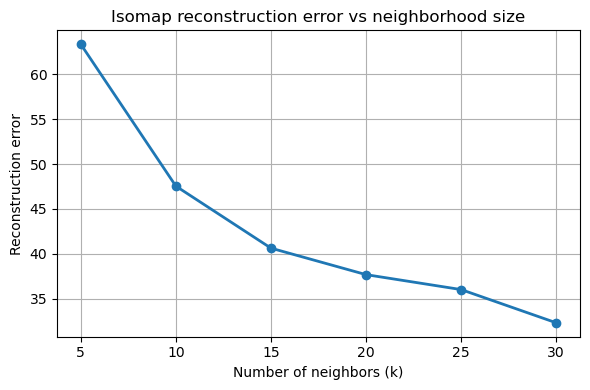

In [98]:
def plot_isomap_elbow(k_values, errors,plotName):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 4))
    plt.plot(k_values, errors, marker='o', linewidth=2)

    plt.xlabel("Number of neighbors (k)")
    plt.ylabel("Reconstruction error")
    plt.title("Isomap reconstruction error vs neighborhood size")

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
    plt.show()

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Ruisseau_Calc_SCA7_isoDim3Neig_elbowPlot.png'
print(curPlotName)
plot_isomap_elbow(
    [5, 10, 15, 20, 25, 30],
    [63.346, 47.538, 40.627, 37.676, 36.011, 32.310],
    curPlotName
)

In [ ]:
################################  Confirmation and plots  #####################################

In [37]:
############################# Parameter and date preparation for plots ##############################
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'
curHem = 'right'

curRegion = 'Calc' # 'POCalCu'
curType = 'min'    
sca = 2
metric = 'Euclidean' #'manhattan'

#inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}'
#              rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
inFileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\{curRegion}_iso_u_with_DB_info\{curRegion}'
               rf'_iso_u_INFO_{curType}_{curHem}_{metric}_SCA_{sca}.csv')
print(inFileName)
merged_info = pd.read_csv(inFileName)
#print(merged_info)
merged_info = merged_info[merged_info['subjID'] != '00035NR'] # Calc outlier, SCA2

C:\B_projWIP\proj_ataxia\Champollion\AtrilBioscaCermoi_Champollion_Regions\Calc_iso_u_with_DB_info\Calc_iso_u_INFO_min_right_Euclidean_SCA_2.csv


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\B_projWIP\\proj_ataxia\\Champollion\\AtrilBioscaCermoi_Champollion_Regions\\Calc_iso_u_with_DB_info\\Calc_iso_u_INFO_min_right_Euclidean_SCA_2.csv'

C:\B_projWIP\proj_ataxia\Champollion\Plots\Ruisseau_Calc_SCA7_isoDim3Neig5Min_Euclidean.png


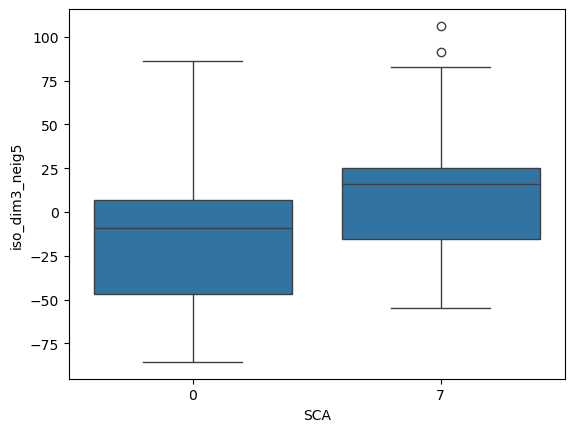

In [75]:
############################  boxplot based on the data defined above  ############################

cur_data = merged_info.copy()  
class_variable = 'SCA'  # Diag, CAG_class, Pyramidal
curX = 'iso_dim3_neig5' # iso3, FPOCalCu
#curX = 'iso_dim1_neig5' # iso1, Calc

sns.boxplot(data=cur_data, x=class_variable, y=curX)


curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Ruisseau_Calc_SCA7_isoDim3Neig5Min_Euclidean.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.close()

In [101]:
inChampF = rf"\B_projWIP\proj_{curProject}\Champollion\Manhattan\Atril_Biosca_Cermoi_iso_u_with_info_sca_2\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_iso_u_INFO.csv"
merged_info = pd.read_csv(inChampF,index_col=0,header=0)

Saving to: C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_Calc_SCA2_isoDim3Neig5_Manhattan_Scatter.png


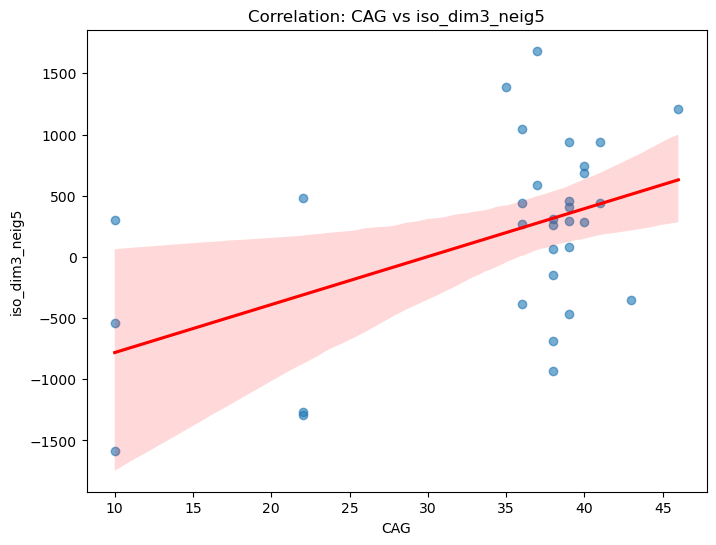

In [111]:
############################  scatter based on the data defined above  ############################

cur_data = merged_info.copy()  
class_variable = 'CAG'  # Independent Variable (X)
curX = 'iso_dim3_neig5' #'iso_dim1_neig5' # Dependent Variable (Y)

# Use regplot to get the scatter points PLUS a regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=cur_data, x=class_variable, y=curX, 
            scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red'})

# Dynamic title based on your variables
plt.title(f'Correlation: {class_variable} vs {curX}')

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_Calc_SCA2_isoDim3Neig5_Manhattan_Scatter.png'
print(f"Saving to: {curPlotName}")

# Uncomment these to save
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.show() # Recommended to see it before closing
#plt.close()

In [39]:
################################  LM tests, parametric  #################################

#diag_measures = ['CAGlong','SARA','INAS']
diag_measures = ['CAGlong']
shape_measures = ['iso1','iso2','iso3']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        #formula = f'{shape_measure} ~ {diag_measure} + Hemisphere + Age + Sex'
        formula = f'{diag_measure} ~ {shape_measure} + Hemisphere + Age + Sex'        
        #formula = f'{shape_measure} ~ {diag_measure} + Age + Sex'   # effect of diagnosis on shape, Test if shape_measure is explained by diagnosis
        #formula = f'{diag_measure} ~ {shape_measure} + Age + Sex'  # effect of shape on diagnosis, test if shape_measure is associated with diagnosis
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

========================= Results for iso1 and CAGlong ===========================
                            OLS Regression Results                            
Dep. Variable:                CAGlong   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     27.85
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           8.51e-10
Time:                        16:21:02   Log-Likelihood:                -74.305
No. Observations:                  43   AIC:                             156.6
Df Residuals:                      39   BIC:                             163.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------